In [1]:
import ast
import sys
import time
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project root importable when running the notebook from notebooks/
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import mlflow

# If your package isn't named "src", change the imports below.
from src.walmart_forecasting.data import load_processed_data
from src.walmart_forecasting.paths import TABLES_DIR
from src.walmart_forecasting.validation import chronological_holdout, expanding_window_splits
from src.walmart_forecasting.experiment import (
    HOLIDAY_WEIGHT,
    NON_HOLIDAY_WEIGHT,
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    FINAL_HOLDOUT_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    save_architecture_result,
    make_run_name,
)
from src.walmart_forecasting.tracking import mlflow_run

np.random.seed(DEFAULT_RANDOM_SEED)
print("Setup complete.")

Setup complete.


In [2]:
ARCHITECTURE = "sarima"
STAGE = "tuning"  # representative_series scope isn't a "final" leaderboard scope
FEATURE_SET = "target_holiday_v1"  # target history + IsHoliday only, per protocol versioning rules
PREPROCESSING = "statistical_target_holiday_v1"
FORECAST_STRATEGY = "local_per_series"
EVALUATION_SCOPE = "representative_series"
TRIAL_NAME = "representative_seasonal_v1"

EXPERIMENT_NAME = "SARIMA_Training"  # one MLflow experiment per architecture

N_SARIMA_SERIES = 30  # deliberately smaller than the ARIMA run -- seasonal fits are much slower
SEASONAL_PERIOD = 52
MAX_ALLOWED_MISSING_WEEKS = 5
EXOG_COLUMNS = ["IsHoliday"]  # kept deliberately small after the ARIMAX overfitting lesson

In [3]:
processed = load_processed_data()
merged_train = processed.train.copy()
merged_train["Date"] = pd.to_datetime(merged_train["Date"])
merged_train = merged_train.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

print(f"Train rows: {len(merged_train):,}")
merged_train.head()

Train rows: 421,570


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [4]:
def build_weekly_series(dataframe, store, dept, date_col="Date", value_col="Weekly_Sales"):
    subset = (
        dataframe[(dataframe["Store"] == store) & (dataframe["Dept"] == dept)]
        .sort_values(date_col)
        .set_index(date_col)
        .asfreq("W-FRI")
    )

    n_missing = int(subset[value_col].isna().sum())

    if n_missing > 0:
        subset[value_col] = subset[value_col].interpolate(limit_direction="both")

    if "IsHoliday" in subset.columns:
        subset["IsHoliday"] = subset["IsHoliday"].fillna(0).astype(float)

    subset["Store"] = store
    subset["Dept"] = dept

    return subset.reset_index(), n_missing

In [5]:
arima_results_path = TABLES_DIR / "arima_baseline_per_series.csv"

order_lookup = {}
if arima_results_path.exists():
    arima_results = pd.read_csv(arima_results_path)
    arima_results["order"] = arima_results["order"].apply(ast.literal_eval)
    order_lookup = {
        (row.Store, row.Dept): row.order for row in arima_results.itertuples()
    }
    sample_pool = arima_results[["Store", "Dept"]].drop_duplicates()
    print(f"Loaded {len(order_lookup)} series orders from {arima_results_path.name}")
else:
    print(f"{arima_results_path.name} not found -- falling back to fresh series selection")
    sample_pool = (
        merged_train.groupby(["Store", "Dept"]).size().reset_index()[["Store", "Dept"]]
    )

selected = sample_pool.sample(
    n=min(N_SARIMA_SERIES, len(sample_pool)), random_state=DEFAULT_RANDOM_SEED
).reset_index(drop=True)

selected_keys = list(zip(selected["Store"], selected["Dept"]))
print(f"Selected {len(selected_keys)} series for SARIMA")


Loaded 300 series orders from arima_baseline_per_series.csv
Selected 30 series for SARIMA


In [6]:
def weighted_mae(actual, forecast, is_holiday):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    weights = np.where(np.asarray(is_holiday, dtype=bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT)
    return float(np.average(np.abs(actual - forecast), weights=weights))


In [8]:
SEASONAL_GRID = [
    (P, D, Q)
    for P in [0, 1]
    for D in [0, 1]
    for Q in [0, 1]
]

FALLBACK_ORDER_GRID = [
    (p, d, q)
    for p in [0, 1]
    for d in [0, 1]
    for q in [0, 1]
]


def resolve_order(store, dept, train_values):
    if (store, dept) in order_lookup:
        return order_lookup[(store, dept)]

    best_order, best_score = (1, 1, 1), np.inf
    for order in FALLBACK_ORDER_GRID:
        try:
            fitted = ARIMA(
                train_values, order=order, enforce_stationarity=False, enforce_invertibility=False
            ).fit()
        except Exception:
            continue
        if fitted.aicc < best_score:
            best_order, best_score = order, fitted.aicc

    return best_order


def best_seasonal_order(train_values, order, seasonal_grid=SEASONAL_GRID, train_exog=None):
    best_seasonal, best_score, best_model = None, np.inf, None

    for P, D, Q in seasonal_grid:
        try:
            fitted = ARIMA(
                train_values,
                exog=train_exog,
                order=order,
                seasonal_order=(P, D, Q, SEASONAL_PERIOD),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit()
        except Exception:
            continue

        if fitted.aicc < best_score:
            best_seasonal, best_score, best_model = (P, D, Q), fitted.aicc, fitted

    return best_seasonal, best_score, best_model


In [9]:
calib_start = time.perf_counter()

for store, dept in selected_keys[:3]:
    series_df, n_missing = build_weekly_series(merged_train, store, dept)
    if n_missing > MAX_ALLOWED_MISSING_WEEKS:
        continue
    order = resolve_order(store, dept, series_df["Weekly_Sales"].values)
    best_seasonal_order(
        series_df["Weekly_Sales"].values, order, train_exog=series_df[EXOG_COLUMNS].values
    )

calib_seconds = time.perf_counter() - calib_start
per_series_seconds = calib_seconds / 3
estimated_total_minutes = (per_series_seconds * len(selected_keys) * 4) / 60

print(f"~{per_series_seconds:.1f}s per series (single seasonal-grid pass)")
print(
    f"Estimated total for {len(selected_keys)} series x 4 evaluation passes "
    f"(3 CV folds + holdout): ~{estimated_total_minutes:.0f} min"
)
print("If this looks too long, lower N_SARIMA_SERIES or trim SEASONAL_GRID and re-run from section 3.")


~4.8s per series (single seasonal-grid pass)
Estimated total for 30 series x 4 evaluation passes (3 CV folds + holdout): ~10 min
If this looks too long, lower N_SARIMA_SERIES or trim SEASONAL_GRID and re-run from section 3.


In [10]:
run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    trial_name=TRIAL_NAME,
)

common_params = build_common_parameters(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(selected_keys),
    random_seed=DEFAULT_RANDOM_SEED,
    extra_parameters={
        "seasonal_grid_size": len(SEASONAL_GRID),
        "seasonal_period": SEASONAL_PERIOD,
        "order_selection_criterion": "aicc",
        "n_series": N_SARIMA_SERIES,
        "orders_reused_from_arima": len(order_lookup),
        "exog_columns": EXOG_COLUMNS,
    },
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
per_series_path = TABLES_DIR / "sarima_baseline_per_series.csv"

with mlflow_run(
    experiment_name=EXPERIMENT_NAME,
    run_name=run_name,
    parameters=common_params,
    tags={"architecture": ARCHITECTURE, "stage": STAGE, "scope": EVALUATION_SCOPE},
) as run:

    per_series_rows = []
    example_forecasts = {}
    fold_wmaes_by_index = defaultdict(list)

    total_fit_seconds = 0.0
    total_predict_seconds = 0.0

    for i, (store, dept) in enumerate(selected_keys):
        series_df, n_missing = build_weekly_series(merged_train, store, dept)

        if n_missing > MAX_ALLOWED_MISSING_WEEKS:
            print(f"[{i+1}/{len(selected_keys)}] Skipping Store {store} Dept {dept}: too many missing weeks")
            continue

        try:
            holdout_split = chronological_holdout(series_df, validation_weeks=FINAL_HOLDOUT_WEEKS)
            cv_splits = expanding_window_splits(
                holdout_split.train, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS
            )
        except ValueError as exc:
            print(f"[{i+1}/{len(selected_keys)}] Skipping Store {store} Dept {dept}: {exc}")
            continue

        order = resolve_order(store, dept, holdout_split.train["Weekly_Sales"].values)

        cv_wmaes = []
        for fold_index, fold in enumerate(cv_splits):
            fold_train_exog = fold.train[EXOG_COLUMNS].values
            fold_valid_exog = fold.validation[EXOG_COLUMNS].values

            fit_start = time.perf_counter()
            seasonal_order, score, model = best_seasonal_order(
                fold.train["Weekly_Sales"].values, order, train_exog=fold_train_exog
            )
            total_fit_seconds += time.perf_counter() - fit_start

            if model is None:
                continue

            predict_start = time.perf_counter()
            forecast = model.forecast(steps=len(fold.validation), exog=fold_valid_exog)
            total_predict_seconds += time.perf_counter() - predict_start

            fold_wmae = weighted_mae(
                fold.validation["Weekly_Sales"].values, forecast, fold.validation["IsHoliday"].values
            )
            cv_wmaes.append(fold_wmae)
            fold_wmaes_by_index[fold_index].append(fold_wmae)

        if not cv_wmaes:
            print(f"[{i+1}/{len(selected_keys)}] Skipping Store {store} Dept {dept}: no CV fold converged")
            continue

        train_exog = holdout_split.train[EXOG_COLUMNS].values
        valid_exog = holdout_split.validation[EXOG_COLUMNS].values

        fit_start = time.perf_counter()
        seasonal_order, score, model = best_seasonal_order(
            holdout_split.train["Weekly_Sales"].values, order, train_exog=train_exog
        )
        total_fit_seconds += time.perf_counter() - fit_start

        if model is None:
            print(f"[{i+1}/{len(selected_keys)}] Skipping Store {store} Dept {dept}: holdout fit failed to converge")
            continue

        predict_start = time.perf_counter()
        forecast = model.forecast(steps=len(holdout_split.validation), exog=valid_exog)
        total_predict_seconds += time.perf_counter() - predict_start

        holdout_actual = holdout_split.validation["Weekly_Sales"].values
        holdout_is_holiday = holdout_split.validation["IsHoliday"].values

        holdout_wmae = weighted_mae(holdout_actual, forecast, holdout_is_holiday)
        holdout_mae = float(np.mean(np.abs(holdout_actual - forecast)))
        holdout_rmse = float(np.sqrt(np.mean((holdout_actual - forecast) ** 2)))

        per_series_rows.append({
            "Store": store,
            "Dept": dept,
            "order": order,
            "seasonal_order": seasonal_order,
            "aicc": score,
            "cv_wmae_mean": float(np.mean(cv_wmaes)),
            "cv_wmae_std": float(np.std(cv_wmaes)),
            "holdout_wmae": holdout_wmae,
            "holdout_mae": holdout_mae,
            "holdout_rmse": holdout_rmse,
            "n_missing_weeks": n_missing,
        })

        example_forecasts[(store, dept)] = {
            "train_dates": holdout_split.train["Date"].values[-26:],
            "train_actual": holdout_split.train["Weekly_Sales"].values[-26:],
            "dates": holdout_split.validation["Date"].values,
            "actual": holdout_actual,
            "forecast": forecast,
        }

        print(
            f"[{i+1}/{len(selected_keys)}] Store {store} Dept {dept}: "
            f"order={order}, seasonal={seasonal_order}, holdout WMAE={holdout_wmae:,.1f}"
        )

    print(f"\nFinished {len(per_series_rows)}/{len(selected_keys)} series.")
    print(f"Total fit time: {total_fit_seconds:.1f}s, total predict time: {total_predict_seconds:.1f}s")

    results_df = pd.DataFrame(per_series_rows)
    overall_metrics = {
        "cv_wmae_mean": float(results_df["cv_wmae_mean"].mean()),
        "cv_wmae_std": float(results_df["cv_wmae_mean"].std()),
        "holdout_wmae": float(results_df["holdout_wmae"].mean()),
        "holdout_mae": float(results_df["holdout_mae"].mean()),
        "holdout_rmse": float(results_df["holdout_rmse"].mean()),
    }

    results_df.to_csv(per_series_path, index=False)

    # Logged inside the run context -- these timestamps land within the same
    # DagsHub run whose duration now spans the whole loop above.
    mlflow.log_metrics({
        **overall_metrics,
        "fit_seconds": total_fit_seconds,
        "predict_seconds": total_predict_seconds,
    })
    mlflow.log_artifact(str(per_series_path))

print("\nOverall (mean across selected series):")
for key, value in overall_metrics.items():
    print(f"  {key}: {value:,.2f}")


Accessing as lchkh23

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

2026/07/08 14:48:07 INFO mlflow.tracking.fluent: Experiment with name 'SARIMA_Training' does not exist. Creating a new experiment.


[1/30] Store 34 Dept 94: order=(0, 1, 2), seasonal=(1, 0, 1), holdout WMAE=2,442.3
[2/30] Store 43 Dept 91: order=(2, 1, 2), seasonal=(0, 0, 1), holdout WMAE=2,394.4
[3/30] Store 22 Dept 56: order=(1, 1, 2), seasonal=(0, 1, 0), holdout WMAE=1,492.2
[4/30] Store 28 Dept 44: order=(2, 1, 2), seasonal=(1, 0, 1), holdout WMAE=419.0
[5/30] Store 32 Dept 92: order=(1, 1, 2), seasonal=(0, 1, 0), holdout WMAE=4,163.6
[6/30] Store 17 Dept 13: order=(1, 1, 2), seasonal=(0, 1, 0), holdout WMAE=1,269.5
[7/30] Store 40 Dept 80: order=(0, 1, 2), seasonal=(1, 0, 1), holdout WMAE=1,115.4
[8/30] Store 25 Dept 5: order=(2, 1, 2), seasonal=(0, 0, 1), holdout WMAE=4,566.2
[9/30] Store 42 Dept 52: order=(0, 1, 2), seasonal=(0, 0, 1), holdout WMAE=10.2
[10/30] Store 21 Dept 14: order=(2, 1, 2), seasonal=(0, 0, 1), holdout WMAE=1,529.4
[11/30] Store 1 Dept 92: order=(2, 1, 2), seasonal=(0, 1, 0), holdout WMAE=5,036.9
[12/30] Store 7 Dept 29: order=(1, 1, 2), seasonal=(1, 0, 1), holdout WMAE=206.8
[13/30] Sto

In [11]:
results_df.sort_values("holdout_wmae")


,Store,Dept,order,seasonal_order,aicc,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,n_missing_weeks
8,42,52,"(0, 1, 2)","(0, 0, 1)",394.118012,12.664886,4.332211,10.154399,8.952911,11.751408,0
20,36,60,"(1, 1, 2)","(1, 0, 1)",573.476743,79.940790,28.702174,84.129442,87.941720,94.696534,0
11,7,29,"(1, 1, 2)","(1, 0, 1)",681.658615,1442.148465,1651.606656,206.817369,227.455573,289.647724,0
13,11,59,"(1, 1, 2)","(1, 0, 1)",727.244937,540.073125,401.568638,318.149487,226.383709,272.158249,0
25,3,87,"(1, 1, 2)","(0, 0, 1)",681.312006,290.097303,46.383080,357.027595,338.586681,415.348351,0
24,38,81,"(2, 1, 2)","(0, 1, 0)",730.437306,470.993558,172.010465,388.771408,393.306730,520.345434,0
3,28,44,"(2, 1, 2)","(1, 0, 1)",743.026121,699.566446,375.496485,419.010541,427.538063,488.789599,0
18,17,17,"(2, 1, 2)","(0, 1, 0)",831.960600,1250.532945,347.597044,828.350346,959.818527,1226.239429,0
6,40,80,"(0, 1, 2)","(1, 0, 1)",804.473975,1281.642003,407.220318,1115.417358,986.095984,1211.031689,0
23,35,17,"(0, 1, 2)","(1, 0, 1)",881.451844,2902.382750,1106.935820,1188.423150,1102.476382,1308.605444,0


In [12]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=run_name,
    stage=STAGE,
    tracker="mlflow",
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(results_df),
    metrics=overall_metrics,
    fit_seconds=total_fit_seconds,
    predict_seconds=total_predict_seconds,
    notes=(
        "SARIMA baseline: (p,d,q) reused from the ARIMA notebook where "
        "available, seasonal (P,D,Q,52) chosen via small AICc grid search. "
        "Representative series, not full dataset."
    ),
)

save_architecture_result(result_row)
print(f"Saved run: {run_name} (CSV + MLflow, MLflow duration reflects full training time)")

Saved run: sarima__tuning__target_holiday_v1__representative_seasonal_v1__s42 (CSV + MLflow, MLflow duration reflects full training time)


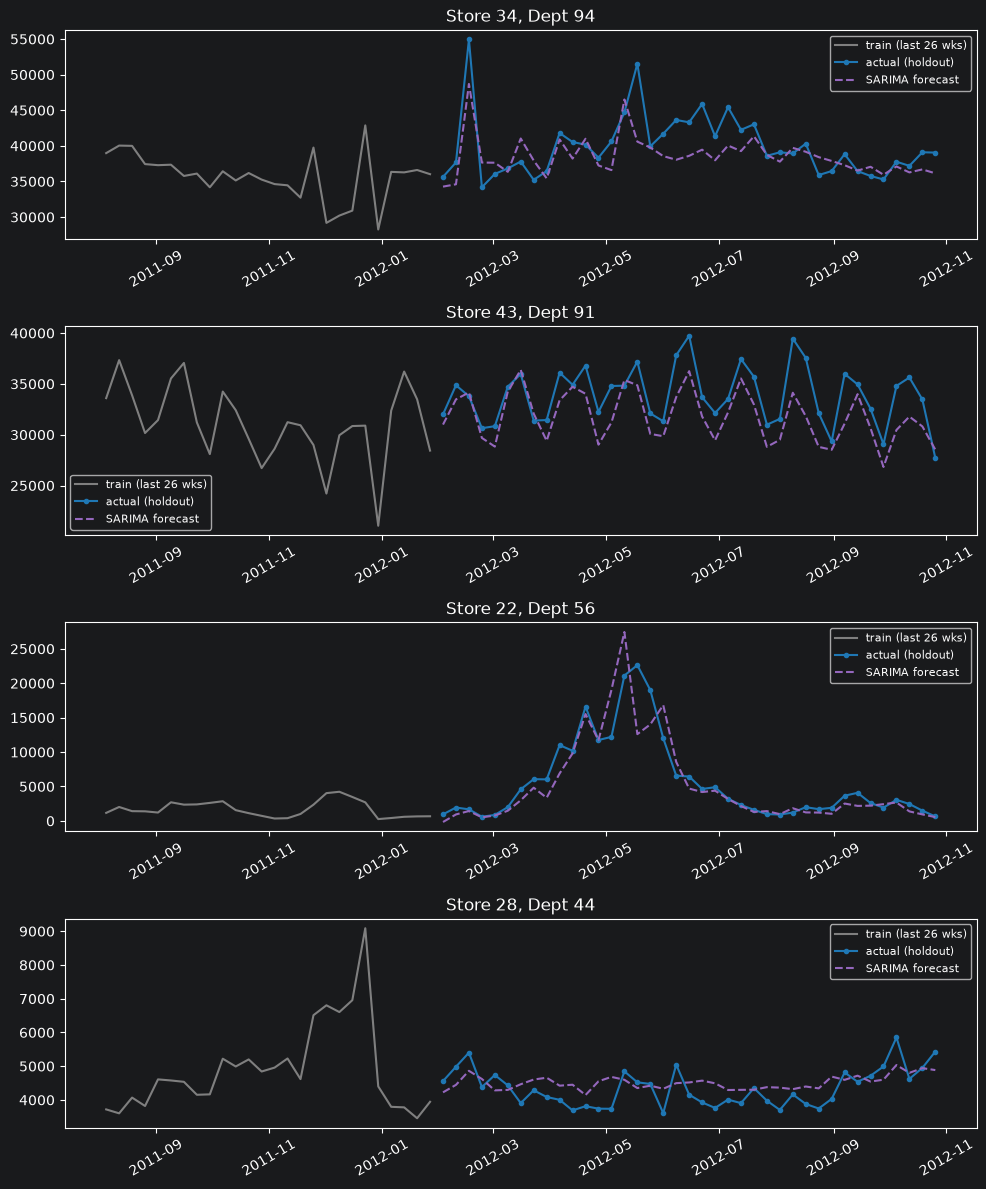

In [13]:
sample_keys = list(example_forecasts.keys())[:4]

fig, axes = plt.subplots(len(sample_keys), 1, figsize=(10, 3 * len(sample_keys)))
if len(sample_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, sample_keys):
    d = example_forecasts[key]
    ax.plot(d["train_dates"], d["train_actual"], label="train (last 26 wks)", color="tab:gray")
    ax.plot(d["dates"], d["actual"], label="actual (holdout)", color="tab:blue", marker="o", markersize=3)
    ax.plot(d["dates"], d["forecast"], label="SARIMA forecast", color="tab:purple", linestyle="--")
    ax.set_title(f"Store {key[0]}, Dept {key[1]}")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [14]:
outlier = merged_train[(merged_train.Store == 27) & (merged_train.Dept == 16)]
print(outlier["Weekly_Sales"].describe())
print("zero or near-zero weeks:", (outlier["Weekly_Sales"] < 100).sum(), "/", len(outlier))

count      143.000000
mean     24741.912517
std      22479.246727
min       2850.360000
25%       6138.745000
50%      16390.770000
75%      38736.690000
max      98262.820000
Name: Weekly_Sales, dtype: float64
zero or near-zero weeks: 0 / 143


In [15]:
example = example_forecasts[(27, 16)]
print("Actual:", example["actual"].round(0))
print("Forecast:", example["forecast"].round(0))

Actual: [ 3009.  3265.  2850.  3105.  4070.  6234. 13699. 25741. 22642. 26456.
 29588. 41926. 33019. 36573. 45093. 60771. 71468. 80531. 50011. 57827.
 58306. 55149. 65563. 37614. 29907. 26758. 26738. 24012. 24200. 21427.
 23113. 16666.  9862.  8345.  5669.  4352.  4815.  5071.  5414.]
Forecast: [ 5.5270e+03  6.6470e+03  9.9700e+02  2.0000e+01  2.2130e+03  1.7220e+03
  1.9780e+03 -1.5110e+03  2.9300e+02 -4.3050e+03  2.0500e+03  2.0800e+02
  1.5830e+03  8.9880e+03  1.7807e+04  6.7280e+03  1.4692e+04  2.6295e+04
  2.1968e+04  1.0487e+04  1.1030e+04  1.5745e+04  1.0785e+04  1.1800e+04
  1.3271e+04  7.5860e+03  7.6480e+03  4.7180e+03  3.2340e+03  6.8460e+03
  3.3160e+03  4.2170e+03  3.5610e+03  2.1370e+03  3.2380e+03  2.4880e+03
  1.8970e+03  1.7090e+03  2.0180e+03]


In [17]:
selected_keys_log = selected_keys  # same series, for a fair comparison

def run_sarima_log_trial():
    per_series_rows_log = []
    for store, dept in selected_keys_log:
        series_df, n_missing = build_weekly_series(merged_train, store, dept)
        if n_missing > MAX_ALLOWED_MISSING_WEEKS:
            continue
        series_df["log_sales"] = np.log1p(series_df["Weekly_Sales"].clip(lower=0))
        try:
            holdout_split = chronological_holdout(series_df, validation_weeks=FINAL_HOLDOUT_WEEKS)
            cv_splits = expanding_window_splits(holdout_split.train, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS)
        except ValueError:
            continue
        order = resolve_order(store, dept, holdout_split.train["Weekly_Sales"].values)
        cv_wmaes = []
        for fold in cv_splits:
            seasonal_order, score, model = best_seasonal_order(
                fold.train["log_sales"].values, order, train_exog=fold.train[EXOG_COLUMNS].values
            )
            if model is None:
                continue
            forecast_log = model.forecast(steps=len(fold.validation), exog=fold.validation[EXOG_COLUMNS].values)
            forecast = np.expm1(forecast_log)  # back-transform
            cv_wmaes.append(weighted_mae(fold.validation["Weekly_Sales"].values, forecast, fold.validation["IsHoliday"].values))
        if not cv_wmaes:
            continue
        seasonal_order, score, model = best_seasonal_order(
            holdout_split.train["log_sales"].values, order, train_exog=holdout_split.train[EXOG_COLUMNS].values
        )
        if model is None:
            continue
        forecast = np.expm1(model.forecast(steps=len(holdout_split.validation), exog=holdout_split.validation[EXOG_COLUMNS].values))
        actual = holdout_split.validation["Weekly_Sales"].values
        holdout_wmae = weighted_mae(actual, forecast, holdout_split.validation["IsHoliday"].values)
        per_series_rows_log.append({
            "Store": store, "Dept": dept, "cv_wmae_mean": float(np.mean(cv_wmaes)),
            "cv_wmae_std": float(np.std(cv_wmaes)), "holdout_wmae": holdout_wmae,
            "holdout_mae": float(np.mean(np.abs(actual - forecast))),
            "holdout_rmse": float(np.sqrt(np.mean((actual - forecast) ** 2))),
        })
    return pd.DataFrame(per_series_rows_log)

results_df_log = run_sarima_log_trial()
overall_metrics_log = {k: float(results_df_log[k].mean()) for k in ["cv_wmae_mean", "cv_wmae_std", "holdout_wmae", "holdout_mae", "holdout_rmse"]}
print("Trial C (log-transform):", overall_metrics_log)

Trial C (log-transform): {'cv_wmae_mean': 9.637906789186544e+112, 'cv_wmae_std': 1.3630058494155342e+113, 'holdout_wmae': 2814.22280187255, 'holdout_mae': 2873.4498103409046, 'holdout_rmse': 3731.0421844974253}


In [18]:
SEASONAL_GRID_WIDE = [(P, D, Q) for P in [0, 1, 2] for D in [0, 1] for Q in [0, 1, 2]]
print(f"Wide grid: {len(SEASONAL_GRID_WIDE)} combos vs original {len(SEASONAL_GRID)}")
# Re-run your Section 7 loop, swapping SEASONAL_GRID -> SEASONAL_GRID_WIDE in the best_seasonal_order() calls

Wide grid: 18 combos vs original 8


In [19]:
def run_sarima_no_exog_trial():
    per_series_rows_noexog = []
    for store, dept in selected_keys:
        series_df, n_missing = build_weekly_series(merged_train, store, dept)
        if n_missing > MAX_ALLOWED_MISSING_WEEKS:
            continue
        try:
            holdout_split = chronological_holdout(series_df, validation_weeks=FINAL_HOLDOUT_WEEKS)
            cv_splits = expanding_window_splits(holdout_split.train, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS)
        except ValueError:
            continue

        order = resolve_order(store, dept, holdout_split.train["Weekly_Sales"].values)

        cv_wmaes = []
        for fold in cv_splits:
            seasonal_order, score, model = best_seasonal_order(
                fold.train["Weekly_Sales"].values, order, train_exog=None  # <- no exog, that's the whole point
            )
            if model is None:
                continue
            forecast = model.forecast(steps=len(fold.validation), exog=None)
            cv_wmaes.append(weighted_mae(fold.validation["Weekly_Sales"].values, forecast, fold.validation["IsHoliday"].values))

        if not cv_wmaes:
            continue

        seasonal_order, score, model = best_seasonal_order(
            holdout_split.train["Weekly_Sales"].values, order, train_exog=None
        )
        if model is None:
            continue
        forecast = model.forecast(steps=len(holdout_split.validation), exog=None)
        actual = holdout_split.validation["Weekly_Sales"].values
        holdout_wmae = weighted_mae(actual, forecast, holdout_split.validation["IsHoliday"].values)

        per_series_rows_noexog.append({
            "Store": store, "Dept": dept,
            "cv_wmae_mean": float(np.mean(cv_wmaes)),
            "cv_wmae_std": float(np.std(cv_wmaes)),
            "holdout_wmae": holdout_wmae,
            "holdout_mae": float(np.mean(np.abs(actual - forecast))),
            "holdout_rmse": float(np.sqrt(np.mean((actual - forecast) ** 2))),
        })

    return pd.DataFrame(per_series_rows_noexog)


results_df_noexog = run_sarima_no_exog_trial()
overall_metrics_noexog = {
    k: float(results_df_noexog[k].mean()) for k in ["cv_wmae_mean", "cv_wmae_std", "holdout_wmae", "holdout_mae", "holdout_rmse"]
}
print("Trial E (no IsHoliday exog):", overall_metrics_noexog)
print("Your original run (with IsHoliday):", {k: overall_metrics[k] for k in overall_metrics_noexog})

Trial E (no IsHoliday exog): {'cv_wmae_mean': 3745.639224684369, 'cv_wmae_std': 2699.485720559886, 'holdout_wmae': 2497.6987320664775, 'holdout_mae': 2599.274540170488, 'holdout_rmse': 3400.6981678641077}
Your original run (with IsHoliday): {'cv_wmae_mean': 3676.2252338127623, 'cv_wmae_std': 5303.559703443716, 'holdout_wmae': 2603.525341452802, 'holdout_mae': 2629.001327509264, 'holdout_rmse': 3425.5257434994733}


In [20]:
with mlflow_run(
    experiment_name=EXPERIMENT_NAME,
    run_name=make_run_name(architecture=ARCHITECTURE, stage=STAGE, feature_set="target_only_v1", trial_name="no_exog_ablation_v1"),
    parameters=build_common_parameters(architecture=ARCHITECTURE, stage=STAGE, feature_set="target_only_v1",
        preprocessing=PREPROCESSING, evaluation_scope=EVALUATION_SCOPE, forecast_strategy=FORECAST_STRATEGY,
        series_count=len(results_df_noexog), extra_parameters={"exog_columns": []}),
    tags={"architecture": ARCHITECTURE, "stage": STAGE, "trial": "no_exog_ablation"},
):
    mlflow.log_metrics(overall_metrics_noexog)

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run sarima__tuning__target_only_v1__no_exog_ablation_v1__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/3/runs/b27a9b615e0d4b78b209948565db44bf
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/3
